In [1]:
import os,h5py
import neurokit2 as nk
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import CubicSpline

In [2]:
DATASET_PATH = "/home/intellisense01/EML-Labs/datasets/iridia-af-records-v1.0.1"
RECORD_NAME = "record_012"
record_path = os.path.join(DATASET_PATH, RECORD_NAME)

In [3]:
print(record_path)
os.listdir(record_path)

/home/intellisense01/EML-Labs/datasets/iridia-af-records-v1.0.1/record_012


['record_012_rr_labels.csv',
 'record_012_rr_00.h5',
 'record_012_ecg_00.h5',
 'record_012_ecg_labels.csv']

In [4]:
rr_labels_df = pd.read_csv(os.path.join(record_path, f"{RECORD_NAME}_rr_labels.csv"))
ecg_labels_df = pd.read_csv(os.path.join(record_path, f"{RECORD_NAME}_ecg_labels.csv"))

In [5]:
rr_labels_df.head()

,start_file_index,start_rr_index,end_file_index,end_rr_index
0,0,58661,0,125030


In [6]:
ecg_labels_df.head()

,start_datetime,start_file_index,start_qrs_index,end_datetime,end_file_index,end_qrs_index,af_duration,nsr_before_duration
0,2016-06-29T00:16:59,0,10261830,2016-06-29T10:01:44,0,17278599,35085,51308


In [85]:
rr = None
ecg = None
with h5py.File(os.path.join(record_path, f"{RECORD_NAME}_ecg_00.h5"), "r") as f:
    print(f.keys())
    print(f["ecg"][:][:,1].shape)
    ecg = f["ecg"][:][:,1]
    # rr = f["rr"][:]

<KeysViewHDF5 ['ecg']>
(17278600,)


In [86]:
with h5py.File(os.path.join(record_path, f"{RECORD_NAME}_rr_00.h5"), "r") as f:
    print(f.keys())
    rr = f["rr"][:]

<KeysViewHDF5 ['rr']>


In [87]:
SR = rr[:58661]
AFIB = rr[58661:125030]
# RR interval Stats
print("SR RR Interval Stats:")
print(f"Max RR Interval: {SR.max():.2f} ms")
print(f"Min RR Interval: {SR.min():.2f} ms")
print(f"Mean: {SR.mean():.2f} ms")
print(f"Median: {np.median(SR):.2f} ms")
print(f"Standard Deviation: {SR.std():.2f} ms")
print("\nAFIB RR Interval Stats:")
print(f"Max RR Interval: {AFIB.max():.2f} ms")
print(f"Min RR Interval: {AFIB.min():.2f} ms")
print(f"Mean: {AFIB.mean():.2f} ms")
print(f"Median: {np.median(AFIB):.2f} ms")
print(f"Standard Deviation: {AFIB.std():.2f} ms")

SR RR Interval Stats:
Max RR Interval: 2260.00 ms
Min RR Interval: 200.00 ms
Mean: 874.66 ms
Median: 885.00 ms
Standard Deviation: 148.95 ms

AFIB RR Interval Stats:
Max RR Interval: 1815.00 ms
Min RR Interval: 200.00 ms
Mean: 528.62 ms
Median: 500.00 ms
Standard Deviation: 116.35 ms


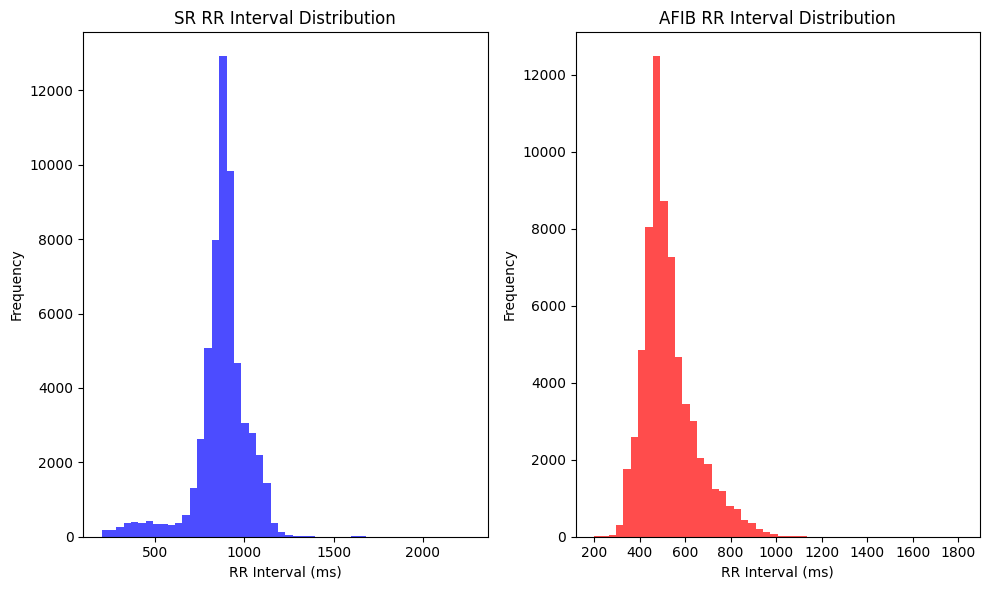

In [88]:
# RR interval distribution
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.hist(SR, bins=50, color='blue', alpha=0.7)
plt.title("SR RR Interval Distribution")
plt.xlabel("RR Interval (ms)")
plt.ylabel("Frequency")
plt.subplot(1, 2, 2)
plt.hist(AFIB, bins=50, color='red', alpha=0.7)
plt.title("AFIB RR Interval Distribution")
plt.xlabel("RR Interval (ms)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [89]:
window_size = 200
stride = 50
segments = []
for i in range(0,len(SR)-window_size, stride):
    segments.append(SR[i:i+window_size])

afib_segments = []
for i in range(0,len(AFIB)-window_size, stride):
    afib_segments.append(AFIB[i:i+window_size])


In [90]:
def CV(rr_intervals):
    return np.std(rr_intervals) / np.mean(rr_intervals) * 100


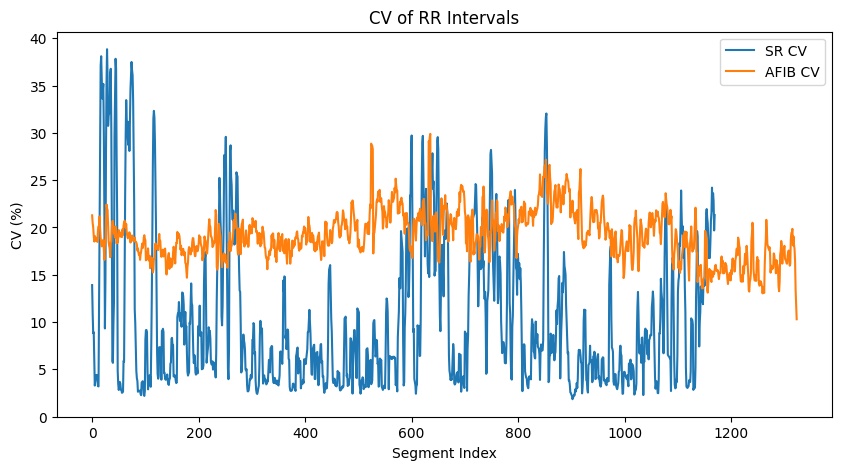

In [91]:
sr_cvs = [CV(segment) for segment in segments]
afib_cvs = [CV(segment) for segment in afib_segments]
plt.figure(figsize=(10, 5))
plt.plot(sr_cvs, label='SR CV')
plt.plot(afib_cvs, label='AFIB CV')
plt.title('CV of RR Intervals')
plt.xlabel('Segment Index')
plt.ylabel('CV (%)')
plt.legend()

In [92]:
def segment_by_time(rr_intervals, window_ms=600000, stride_ms=600000):
    segments = []
    n = len(rr_intervals)

    start = 0

    while start < n:
        total = 0
        end = start

        # Expand window until reaching 10 minutes
        while end < n and total < window_ms:
            total += rr_intervals[end]
            end += 1

        if total >= window_ms:
            segments.append(rr_intervals[start:end])

        # Move start forward by stride (in time, not index)
        stride_sum = 0
        new_start = start

        while new_start < n and stride_sum < stride_ms:
            stride_sum += rr_intervals[new_start]
            new_start += 1

        start = new_start

    return segments

In [99]:
sr_segments = segment_by_time(SR, window_ms=600000, stride_ms=600000)
afib_segments = segment_by_time(AFIB, window_ms=600000, stride_ms=600000)


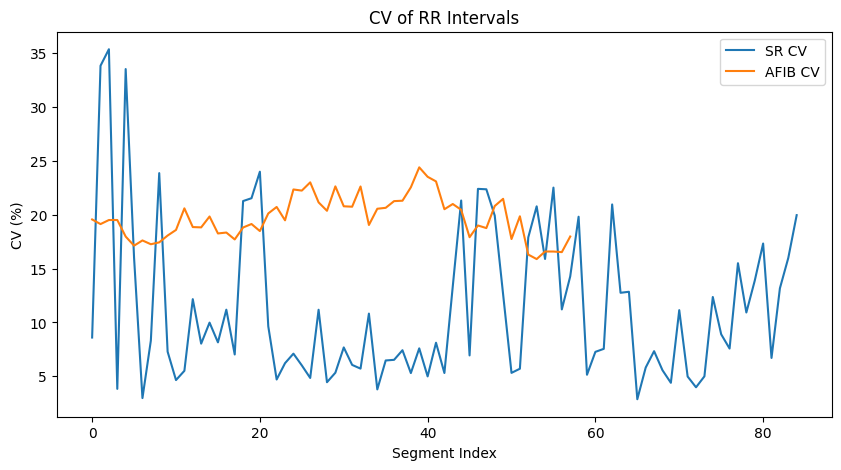

In [100]:
sr_cvs = [CV(segment) for segment in sr_segments]
afib_cvs = [CV(segment) for segment in afib_segments]
plt.figure(figsize=(10, 5))
plt.plot(sr_cvs, label='SR CV')
plt.plot(afib_cvs, label='AFIB CV')
plt.title('CV of RR Intervals')
plt.xlabel('Segment Index')
plt.ylabel('CV (%)')
plt.legend()
plt.show()


In [211]:
def filter_segment(rr_intervals,threshold=10000,minimum_rr_interval=200,maximum_rr_interval=5000):
    mask = (rr_intervals >= minimum_rr_interval) & (rr_intervals <= maximum_rr_interval)
    rr_intervals_less_than_200_and_greater_than_5000 = rr_intervals[~mask]
    if not mask.all():
        print(f"Sum of rr intervals less than 200 and greater than 5000: {sum(rr_intervals_less_than_200_and_greater_than_5000)}")
        return None
    cleaned_rr_intervals = rr_intervals[mask]
    return cleaned_rr_intervals

In [217]:
def resample_segment(rr_intervals, target_len=600):
    # Prepend 0 so r_peaks represents actual R-peak times
    r_peaks = np.concatenate([[0], np.cumsum(rr_intervals)]) / 1000.0

    rri = rr_intervals / 1000.0  # no diff needed, no data lost

    if len(rri) < 2:
        return None

    t_original = r_peaks[1:]

    t_uniform = np.linspace(t_original[0], t_original[-1], target_len)

    cs = CubicSpline(t_original, rri)
    resampled = cs(t_uniform)
    if resampled.min() < 0.2 or resampled.max() > 5.0:
        print(f"Resampled RR intervals have values less than 200 or greater than 5000")
        return None
    return resampled

In [218]:
def process_segments(rr_intervals):
    segments = segment_by_time(rr_intervals)

    processed = []
    for i, seg in enumerate(segments):
        filtered = filter_segment(seg)
        if filtered is not None:
            resampled = resample_segment(filtered, target_len=600)
            if resampled is not None:
                processed.append(resampled)
        else:
            print(f"Segment {i} removed because of artifacts")

    return np.array(processed)

In [219]:
X = process_segments(SR)
Y = process_segments(AFIB)

Resampled RR intervals have values less than 200 or greater than 5000
Resampled RR intervals have values less than 200 or greater than 5000
Resampled RR intervals have values less than 200 or greater than 5000
Resampled RR intervals have values less than 200 or greater than 5000
Resampled RR intervals have values less than 200 or greater than 5000
Resampled RR intervals have values less than 200 or greater than 5000
Resampled RR intervals have values less than 200 or greater than 5000
Resampled RR intervals have values less than 200 or greater than 5000
Resampled RR intervals have values less than 200 or greater than 5000
Resampled RR intervals have values less than 200 or greater than 5000
Resampled RR intervals have values less than 200 or greater than 5000
Resampled RR intervals have values less than 200 or greater than 5000
Resampled RR intervals have values less than 200 or greater than 5000
Resampled RR intervals have values less than 200 or greater than 5000
Resampled RR interva

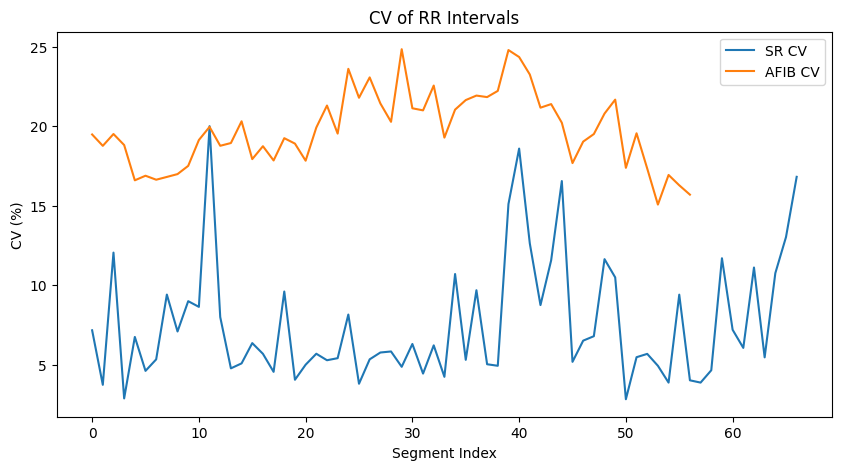

In [220]:
sr_cvs = [CV(segment) for segment in X]
afib_cvs = [CV(segment) for segment in Y]
plt.figure(figsize=(10, 5))
plt.plot(sr_cvs, label='SR CV')
plt.plot(afib_cvs, label='AFIB CV')
plt.title('CV of RR Intervals')
plt.xlabel('Segment Index')
plt.ylabel('CV (%)')
plt.legend()
plt.show()

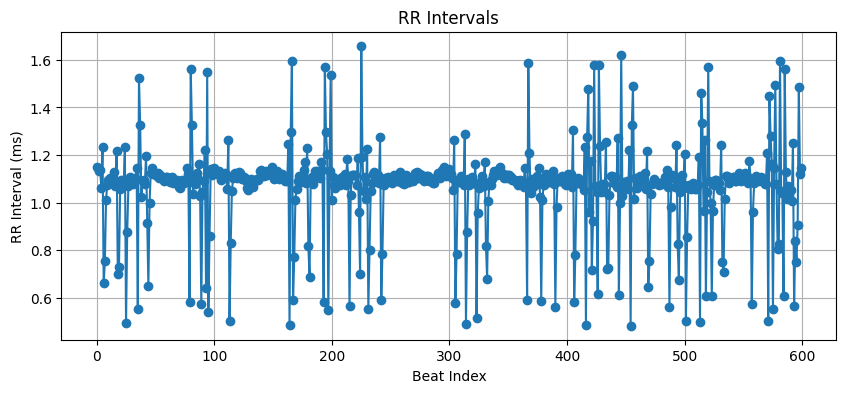

In [223]:
window_01 = X[66]
plt.figure(figsize=(10, 4))
plt.plot(window_01, marker='o')
plt.title('RR Intervals')
plt.xlabel('Beat Index')
plt.ylabel('RR Interval (ms)')
plt.grid()
plt.show()

In [49]:
last_10_segments = segments[-200:]
# for i, segment in enumerate(last_10_segments):
#     min_rr = segment.min()
#     max_rr = segment.max()
#     mean_rr = segment.mean()
#     plt.figure(figsize=(10, 4))
#     plt.plot(segment, marker='o')
#     plt.axhline(min_rr, color='green', linestyle='--', label=f'Min: {min_rr:.2f} ms')
#     plt.axhline(max_rr, color='red', linestyle='--', label=f'Max: {max_rr:.2f} ms')
#     plt.axhline(mean_rr, color='blue', linestyle='--', label=f'Mean: {mean_rr:.2f} ms')
#     plt.legend()
#     plt.title(f"SR RR Interval Segment {len(segments)-10 + i + 1}")
#     plt.xlabel("Beat Index")
#     plt.ylabel("RR Interval (ms)")
#     plt.grid()
#     plt.show()

In [50]:
def filter_advanced_artifacts(rr_intervals: np.ndarray, lower_bound_ratio: float = 0.75, upper_bound_ratio: float = 1.25):
    local_baseline = np.median(rr_intervals)
    lower_bound = local_baseline * lower_bound_ratio
    upper_bound = local_baseline * upper_bound_ratio
    
    filtered = []
    i = 0
    length = len(rr_intervals)
    
    while i < length:
        current_rr = rr_intervals[i]
        
        # Check if the beat is suspiciously short
        if current_rr < lower_bound and i + 1 < length:
            next_rr = rr_intervals[i+1]
            merged_rr = current_rr + next_rr
            
            # Scenario A: It's a perfect split beat. Merging them fixes it.
            if lower_bound <= merged_rr <= upper_bound:
                filtered.append(merged_rr)
                i += 2  # Consume both beats
                continue
                
            # Scenario B: It's an isolated false peak (noise). 
            # Adding it to the next beat makes it too massive.
            elif merged_rr > upper_bound:
                # DROP the current isolated short beat. Just skip it.
                i += 1 
                continue
                
            # Scenario C: The noise is so bad that merging TWO beats is still too short.
            # (e.g., the beat shattered into 3 pieces). Drop the fragment and move on.
            else:
                i += 1
                continue

        # Scenario D: Normal beat (or physiological ectopic beat)
        filtered.append(current_rr)
        i += 1
        
    return np.array(filtered)

filtered_segments = [filter(segment) for segment in last_10_segments]
# for i, segment in enumerate(filtered_segments):
#     min_rr = segment.min()
#     max_rr = segment.max()
#     mean_rr = segment.mean()
#     plt.figure(figsize=(10, 4))
#     plt.plot(segment, marker='o')
#     plt.axhline(min_rr, color='green', linestyle='--', label=f'Min: {min_rr:.2f} ms')
#     plt.axhline(max_rr, color='red', linestyle='--', label=f'Max: {max_rr:.2f} ms')
#     plt.axhline(mean_rr, color='blue', linestyle='--', label=f'Mean: {mean_rr:.2f} ms')
#     plt.legend()
#     plt.title(f"Filtered SR RR Interval Segment {len(segments)-10 + i + 1}")
#     plt.xlabel("Beat Index")
#     plt.ylabel("RR Interval (ms)")
#     plt.grid()
#     plt.show()


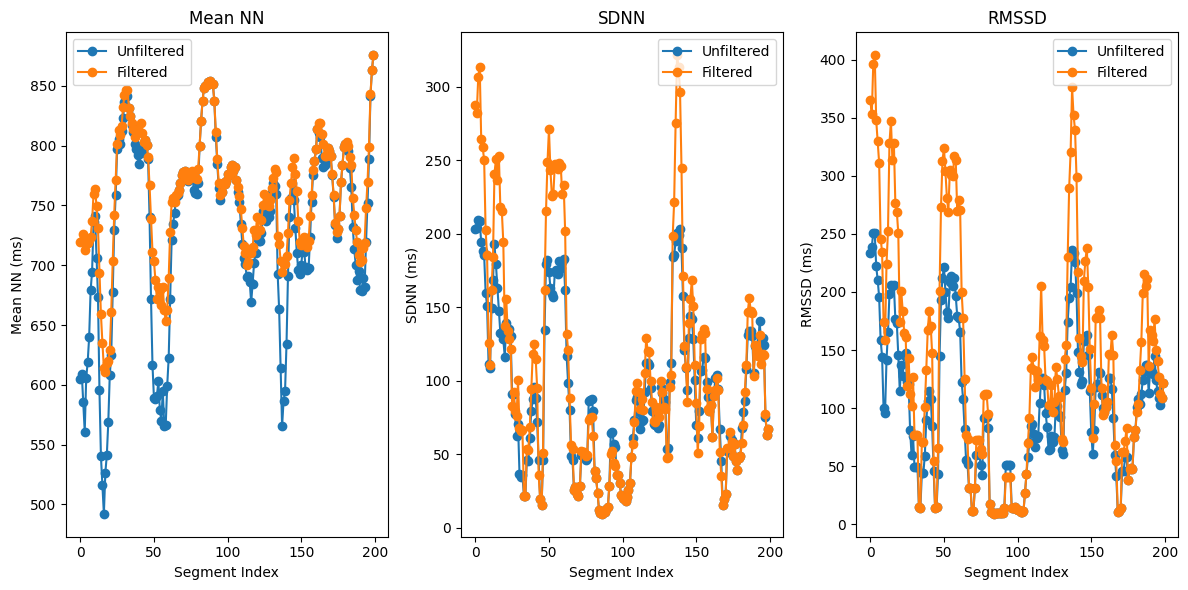

In [51]:
unfilterd_hrvs = []
filtered_hrvs = []
unfiltered_segments = [segment for segment in last_10_segments]
for i in range(len(unfiltered_segments)):
    r_peaks = nk.intervals_to_peaks(unfiltered_segments[i], sampling_rate=200)
    hrv_time = nk.hrv_time(r_peaks, sampling_rate=200)
    unfilterd_hrvs.append(hrv_time[['HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD']])

for i in range(len(filtered_segments)):
    r_peaks = nk.intervals_to_peaks(filtered_segments[i], sampling_rate=200)
    hrv_time = nk.hrv_time(r_peaks, sampling_rate=200)
    filtered_hrvs.append(hrv_time[['HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD']])


plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot([hrv['HRV_MeanNN'].values[0] for hrv in unfilterd_hrvs], label='Unfiltered', marker='o')
plt.plot([hrv['HRV_MeanNN'].values[0] for hrv in filtered_hrvs], label='Filtered', marker='o')
plt.title('Mean NN')
plt.xlabel('Segment Index')
plt.ylabel('Mean NN (ms)')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot([hrv['HRV_SDNN'].values[0] for hrv in unfilterd_hrvs], label='Unfiltered', marker='o')
plt.plot([hrv['HRV_SDNN'].values[0] for hrv in filtered_hrvs], label='Filtered', marker='o')
plt.title('SDNN')
plt.xlabel('Segment Index')
plt.ylabel('SDNN (ms)')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot([hrv['HRV_RMSSD'].values[0] for hrv in unfilterd_hrvs], label='Unfiltered', marker='o')
plt.plot([hrv['HRV_RMSSD'].values[0] for hrv in filtered_hrvs], label='Filtered', marker='o')
plt.title('RMSSD')
plt.xlabel('Segment Index')
plt.ylabel('RMSSD (ms)')
plt.legend()
plt.tight_layout()
plt.show()


In [52]:
limit = 35*60*1000 # 35 minutes in milliseconds
rr_inversed = SR[::-1]
cumulative_sum = np.cumsum(rr_inversed)
index_35min = np.searchsorted(cumulative_sum, limit)
print(f"Number of beats in the last 35 minutes: {index_35min}")

Number of beats in the last 35 minutes: 2769


In [ ]:
window_size = 5*60*1000 # 5 minutes in milliseconds
stride = 1*60*1000 # 1 minute in milliseconds
segments_5min = []
cumulative_sum = np.cumsum(SR)
for start in range(0, cumulative_sum[-1] - window_size, stride):
    end = start + window_size
    start_idx = np.searchsorted(cumulative_sum, start)
    end_idx = np.searchsorted(cumulative_sum, end)
    time_to_AF = cumulative_sum[start_idx] / 1000 / 60 # Convert to minutes
    segments_5min.append((SR[start_idx:end_idx], time_to_AF))

In [65]:
df = pd.DataFrame()
time_to_AF = 0
for i, (segment, time_to_AF) in enumerate(segments_5min):
    r_peaks = nk.intervals_to_peaks(segment, sampling_rate=200)
    hrv_time = nk.hrv_time(r_peaks, sampling_rate=200)
    hrv_time['Segment'] = i
    hrv_time['Time_to_AF'] = time_to_AF
    df = pd.concat([df, hrv_time[['Segment', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'Time_to_AF']]], ignore_index=True)
    
   

In [66]:
df = df.sort_values(by='Time_to_AF').reset_index(drop=True)[df['Time_to_AF'] <= 35]
df.tail()

,Segment,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,Time_to_AF
30,30,596.510934,159.181808,166.318977,30.005667
31,31,593.745059,165.613938,174.006231,31.001917
32,32,593.881188,166.987744,174.338176,32.001667
33,33,632.784810,154.653155,151.602434,33.006333
34,34,660.319383,141.409482,132.483703,34.003250


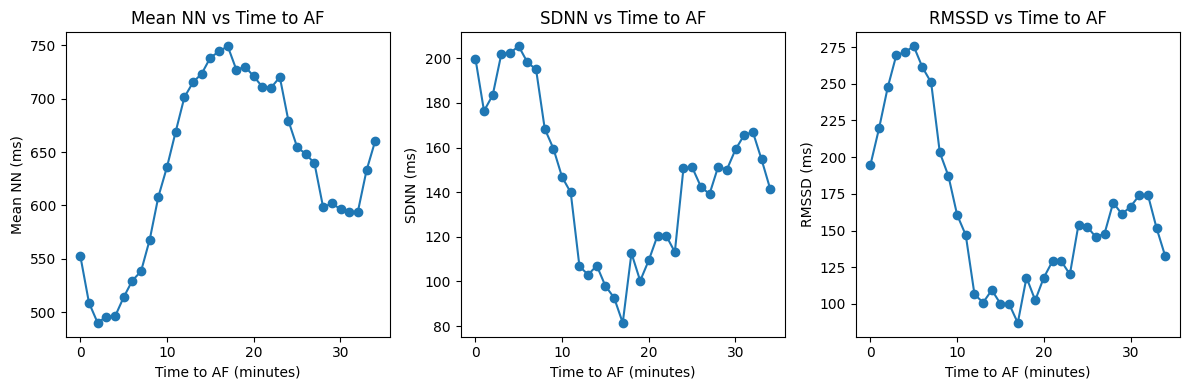

In [67]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(df['Time_to_AF'], df['HRV_MeanNN'], marker='o')
plt.title('Mean NN vs Time to AF')
plt.xlabel('Time to AF (minutes)')
plt.ylabel('Mean NN (ms)')
plt.subplot(1, 3, 2)
plt.plot(df['Time_to_AF'], df['HRV_SDNN'], marker='o')
plt.title('SDNN vs Time to AF')
plt.xlabel('Time to AF (minutes)')
plt.ylabel('SDNN (ms)')
plt.subplot(1, 3, 3)
plt.plot(df['Time_to_AF'], df['HRV_RMSSD'], marker='o')
plt.title('RMSSD vs Time to AF')
plt.xlabel('Time to AF (minutes)')
plt.ylabel('RMSSD (ms)')
plt.tight_layout()
plt.show()

/home/intellisense01/EML-Labs/datasets/Data-Explorer/lib/python3.12/site-packages/neurokit2/ecg/ecg_plot.py:68: NeuroKitWarning: 'info' dict not provided. Some information might be missing. Sampling rate will be set to 1000 Hz.
  warn(


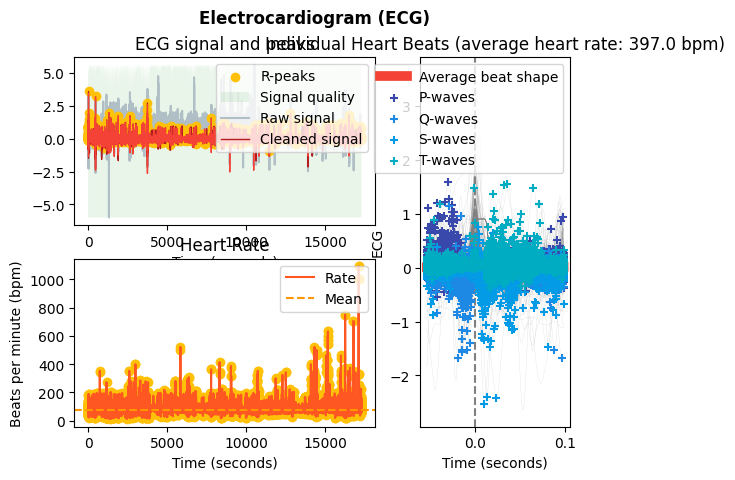

In [9]:
ecg_clean,info = nk.ecg_process(ecg, sampling_rate=200)
nk.ecg_plot(ecg_clean)

In [10]:
PROCESSED_DATA_DIR = os.path.join(os.getcwd(), 'processed_data_60min_nsr_5min_af')
# data = np.load(os.path.join(PROCESSED_DATA_DIR, "record_153_af2833s_nsr49131s_rr.npy"))

In [11]:
plt.figure(figsize=(15,5))
plt.plot(data)
plt.title("RR Intervals")
plt.xlabel("Time (s)")
plt.ylabel("RR Interval (ms)")
plt.grid()
plt.show()

NameError: name 'data' is not defined

<Figure size 1500x500 with 0 Axes>

In [16]:
list_of_files = os.listdir(PROCESSED_DATA_DIR)
print(list_of_files[:20])

['record_015_0_47.npy', 'record_072_0_130.npy', 'record_132_0_205.npy', 'record_117_0_175.npy', 'record_145_1_101.npy', 'record_051_3_84.npy', 'record_147_0_17.npy', 'record_131_0_203.npy', 'record_111_2_157.npy', 'record_031_0_15.npy', 'record_119_0_140.npy', 'record_038_0_76.npy', 'record_060_0_123.npy', 'record_001_3_9.npy', 'record_130_0_227.npy', 'record_034_4_17.npy', 'record_113_0_94.npy', 'record_077_4_9.npy', 'record_038_0_74.npy', 'record_040_0_29.npy']


In [17]:
data = []
for file in list_of_files:
    if file.endswith(".npy"):
        data.append(np.load(os.path.join(PROCESSED_DATA_DIR, file)))

In [18]:
min_length = min(len(d) for d in data)
data = [d[-min_length:] for d in data] # Truncate to the shortest length
data = np.array(data)
print(data.shape)

(46463, 200)


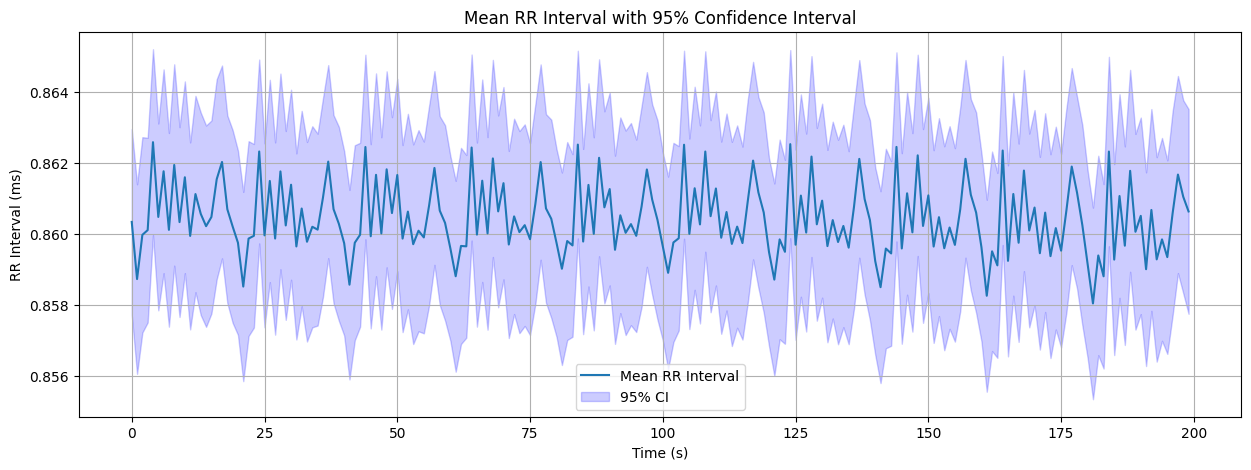

In [19]:
mean_windows = np.mean(data, axis=0)
std_windows = np.std(data, axis=0)
ci_95 = 1.96 * std_windows / np.sqrt(data.shape[0])
plt.figure(figsize=(15,5))
plt.plot(mean_windows, label="Mean RR Interval")
plt.fill_between(range(len(mean_windows)), mean_windows - ci_95, mean_windows + ci_95, color='b', alpha=0.2, label="95% CI")
plt.title("Mean RR Interval with 95% Confidence Interval")
plt.xlabel("Time (s)")
plt.ylabel("RR Interval (ms)")
plt.legend()
plt.grid()
plt.show()

In [20]:
def RMSSD(rr_intervals):
    diff = np.diff(rr_intervals)
    return np.sqrt(np.mean(diff**2))

def pNN50(rr_intervals):
    diff = np.diff(rr_intervals)
    return np.sum(np.abs(diff) > 0.05) / len(diff) * 100 # Since RR intervals in seconds, 50ms = 0.05s

def SDNN(rr_intervals):
    return np.std(rr_intervals)

def sample_entropy(rr_intervals, m=2, r=0.2):
    sample_entropy_, _ = nk.entropy_sample(rr_intervals, dimension=m, tolerance=r * np.std(rr_intervals))
    return sample_entropy_

def approximate_entropy(rr_intervals, m=2, r=0.2):
    approximate_entropy_, _ = nk.entropy_approximate(rr_intervals, dimension=m, tolerance=r * np.std(rr_intervals))
    return approximate_entropy_

def alpha_1(rr_intervals):
    alpha_1_, _ = nk.complexity_dfa(rr_intervals, order=1)
    return alpha_1_

In [21]:
random_sample_entropy = sample_entropy(np.random.rand(1000))
print(f"Sample Entropy of random data: {random_sample_entropy}")

random_approx_entropy = approximate_entropy(np.random.rand(1000))
print(f"Approximate Entropy of random data: {random_approx_entropy}")

Sample Entropy of random data: 2.1969128566354406
Approximate Entropy of random data: 1.791669956448919


In [22]:
window_length = 200 # 200 RR intervals
stride = 10 # 10 RR interval stride
rmssd_values = []
pnn50_values = []
alpha1_values = []
sample_entropy_values = []
approximate_entropy_values = []
for record in data:
    rmssd_record = []
    pnn50_record = []
    alpha_1_record = []
    sample_entropy_record = []
    approximate_entropy_record = []
    for start in range(0, len(record) - window_length + 1, stride):
        window = record[start:start+window_length]
        rmssd_record.append(RMSSD(window))
        pnn50_record.append(pNN50(window))
        alpha_1_record.append(alpha_1(window))
        sample_entropy_record.append(sample_entropy(window))
        approximate_entropy_record.append(approximate_entropy(window))

    rmssd_values.append(rmssd_record)
    pnn50_values.append(pnn50_record)
    alpha1_values.append(alpha_1_record)
    sample_entropy_values.append(sample_entropy_record)
    approximate_entropy_values.append(approximate_entropy_record)
    

In [23]:
print(len(data))
print(len(rmssd_values))
print(len(rmssd_values[0]))
print(len(pnn50_values))

46463
46463
1
46463


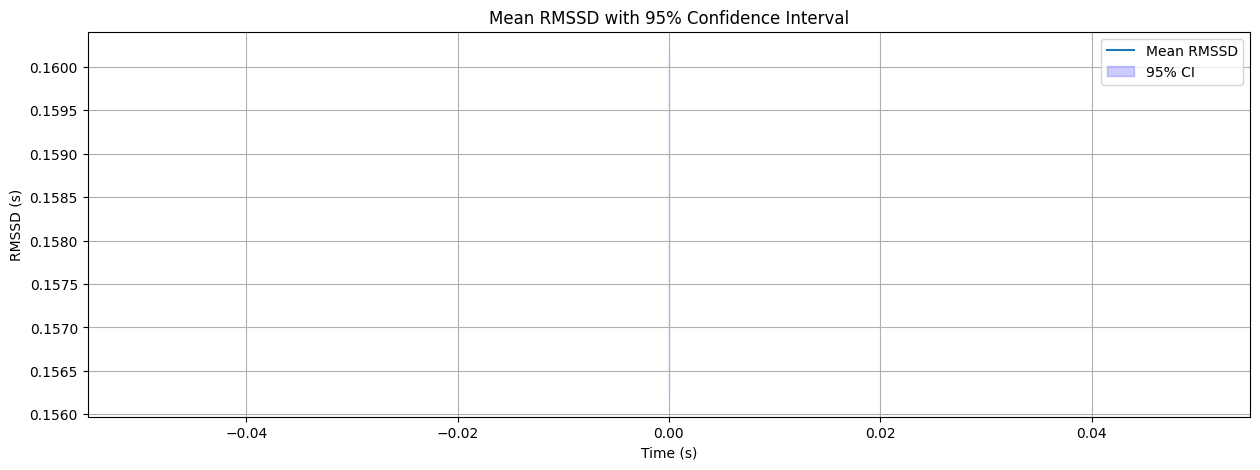

In [24]:
mean_rmssd = np.mean(rmssd_values, axis=0)
std_rmssd = np.std(rmssd_values, axis=0)
ci_95_rmssd = 1.96 * std_rmssd / np.sqrt(len(rmssd_values))
plt.figure(figsize=(15,5))
plt.plot(mean_rmssd, label="Mean RMSSD")
plt.fill_between(range(len(mean_rmssd)), mean_rmssd - ci_95_rmssd, mean_rmssd + ci_95_rmssd, color='b', alpha=0.2, label="95% CI")
plt.title("Mean RMSSD with 95% Confidence Interval")
plt.xlabel("Time (s)")
plt.ylabel("RMSSD (s)")
plt.legend()
plt.grid()
plt.show()

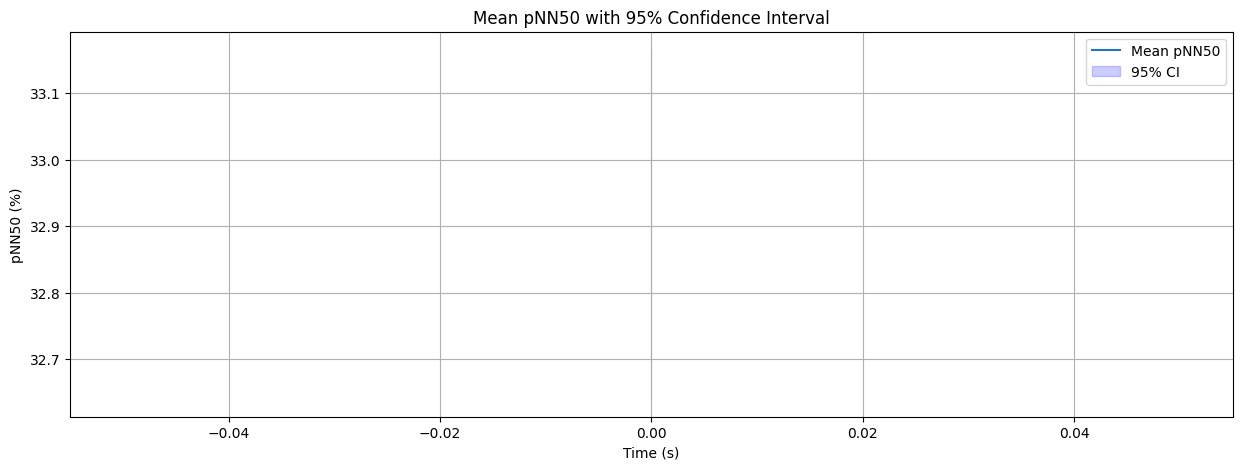

In [25]:
mean_pnn50 = np.mean(pnn50_values, axis=0)
std_pnn50 = np.std(pnn50_values, axis=0)
ci_95_pnn50 = 1.96 * std_pnn50 / np.sqrt(len(pnn50_values))
plt.figure(figsize=(15,5))
plt.plot(mean_pnn50, label="Mean pNN50")
plt.fill_between(range(len(mean_pnn50)), mean_pnn50 - ci_95_pnn50, mean_pnn50 + ci_95_pnn50, color='b', alpha=0.2, label="95% CI")
plt.title("Mean pNN50 with 95% Confidence Interval")
plt.xlabel("Time (s)")      
plt.ylabel("pNN50 (%)")
plt.legend()
plt.grid()
plt.show()

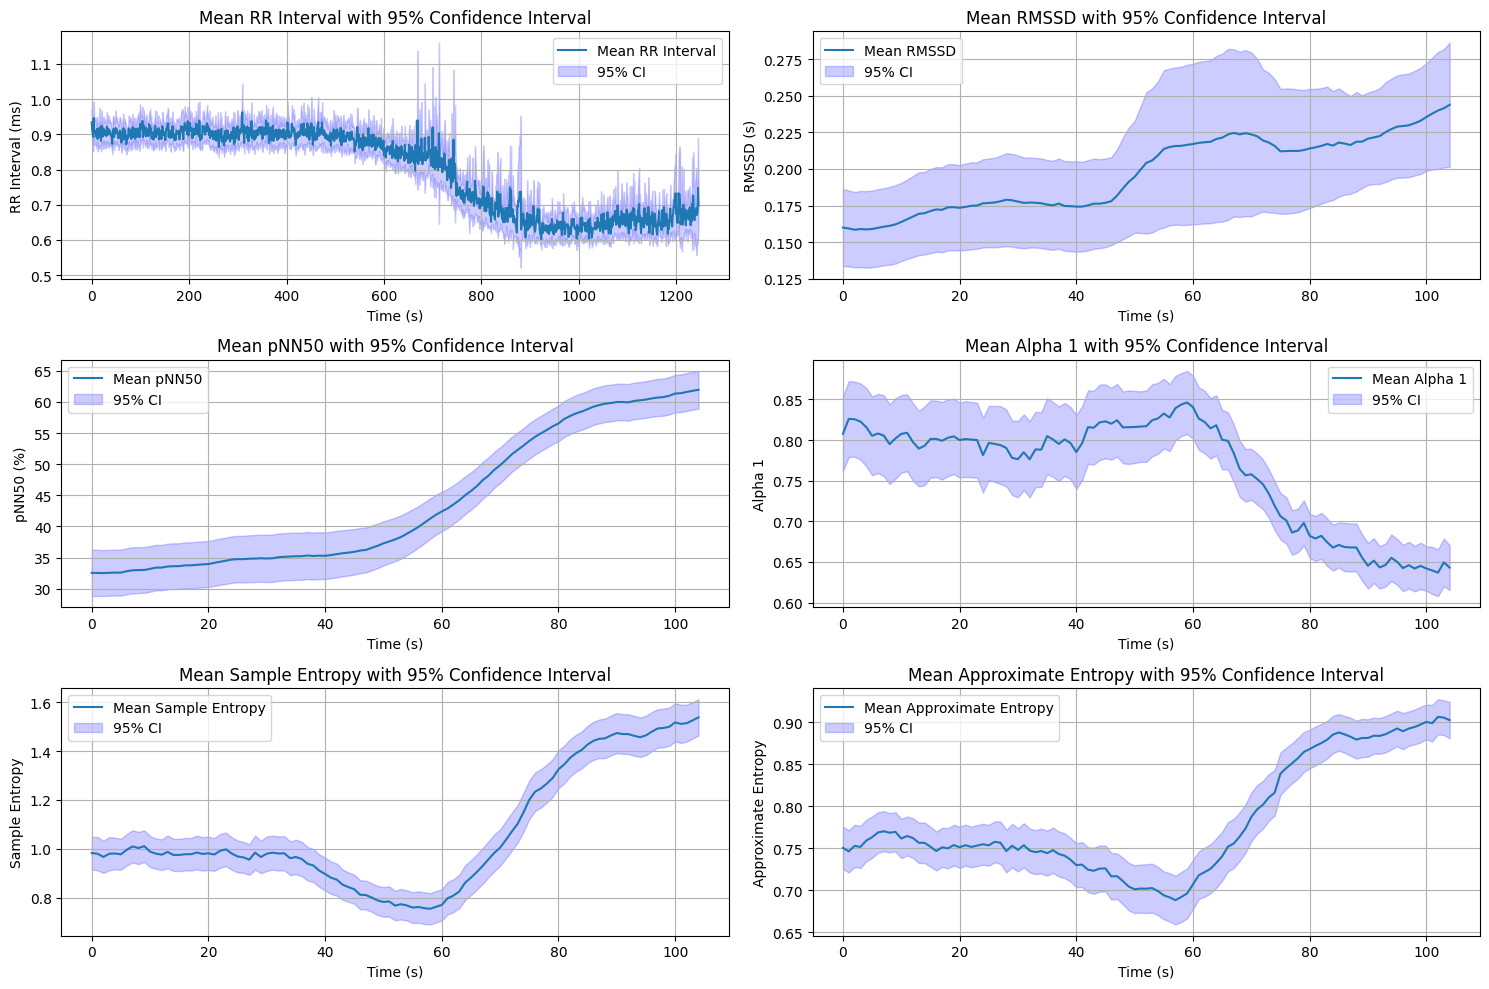

In [89]:
mean_rr = np.mean(data, axis=0)
std_rr = np.std(data, axis=0)
ci_95_rr = 1.96 * std_rr / np.sqrt(data.shape[0])


mean_rmssd = np.mean(rmssd_values, axis=0)
std_rmssd = np.std(rmssd_values, axis=0)
ci_95_rmssd = 1.96 * std_rmssd / np.sqrt(len(rmssd_values))

mean_pnn50 = np.mean(pnn50_values, axis=0)
std_pnn50 = np.std(pnn50_values, axis=0)
ci_95_pnn50 = 1.96 * std_pnn50 / np.sqrt(len(pnn50_values))

mean_alpha1 = np.mean(alpha1_values, axis=0)
std_alpha1 = np.std(alpha1_values, axis=0)
ci_95_alpha1 = 1.96 * std_alpha1 / np.sqrt(len(alpha1_values))

mean_sample_entropy = np.mean(sample_entropy_values, axis=0)
std_sample_entropy = np.std(sample_entropy_values, axis=0)
ci_95_sample_entropy = 1.96 * std_sample_entropy / np.sqrt(len(sample_entropy_values))

mean_approximate_entropy = np.mean(approximate_entropy_values, axis=0)
std_approximate_entropy = np.std(approximate_entropy_values, axis=0)
ci_95_approximate_entropy = 1.96 * std_approximate_entropy / np.sqrt(len(approximate_entropy_values))

plt.figure(figsize=(15,10))
plt.subplot(3,2,1)
plt.plot(mean_rr, label="Mean RR Interval")
plt.fill_between(range(len(mean_rr)), mean_rr - ci_95_rr, mean_rr + ci_95_rr, color='b', alpha=0.2, label="95% CI")
plt.title("Mean RR Interval with 95% Confidence Interval")
plt.xlabel("Time (s)")
plt.ylabel("RR Interval (ms)")
plt.legend()
plt.grid()

plt.subplot(3,2,2)
plt.plot(mean_rmssd, label="Mean RMSSD")
plt.fill_between(range(len(mean_rmssd)), mean_rmssd - ci_95_rmssd, mean_rmssd + ci_95_rmssd, color='b', alpha=0.2, label="95% CI")
plt.title("Mean RMSSD with 95% Confidence Interval")
plt.xlabel("Time (s)")
plt.ylabel("RMSSD (s)")
plt.legend()
plt.grid()  

plt.subplot(3,2,3)
plt.plot(mean_pnn50, label="Mean pNN50")
plt.fill_between(range(len(mean_pnn50)), mean_pnn50 - ci_95_pnn50, mean_pnn50 + ci_95_pnn50, color='b', alpha=0.2, label="95% CI")
plt.title("Mean pNN50 with 95% Confidence Interval")
plt.xlabel("Time (s)")
plt.ylabel("pNN50 (%)")
plt.legend()
plt.grid()

plt.subplot(3,2,4)
plt.plot(mean_alpha1, label="Mean Alpha 1")
plt.fill_between(range(len(mean_alpha1)), mean_alpha1 - ci_95_alpha1, mean_alpha1 + ci_95_alpha1, color='b', alpha=0.2, label="95% CI")
plt.title("Mean Alpha 1 with 95% Confidence Interval")
plt.xlabel("Time (s)")
plt.ylabel("Alpha 1")
plt.legend()
plt.grid()

plt.subplot(3,2,5)
plt.plot(mean_sample_entropy, label="Mean Sample Entropy")
plt.fill_between(range(len(mean_sample_entropy)), mean_sample_entropy - ci_95_sample_entropy, mean_sample_entropy + ci_95_sample_entropy, color='b', alpha=0.2, label="95% CI")
plt.title("Mean Sample Entropy with 95% Confidence Interval")
plt.xlabel("Time (s)")
plt.ylabel("Sample Entropy")
plt.legend()
plt.grid()

plt.subplot(3,2,6)
plt.plot(mean_approximate_entropy, label="Mean Approximate Entropy")
plt.fill_between(range(len(mean_approximate_entropy)), mean_approximate_entropy - ci_95_approximate_entropy, mean_approximate_entropy + ci_95_approximate_entropy, color='b', alpha=0.2, label="95% CI")
plt.title("Mean Approximate Entropy with 95% Confidence Interval")
plt.xlabel("Time (s)")
plt.ylabel("Approximate Entropy")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("comparison_of_different_metrics.png", dpi=300, bbox_inches='tight')
plt.show()